In [1]:
import pandas as pd
import numpy as np
import scipy.stats as st
import statsmodels.formula.api as smf
import statsmodels.stats as sms
import statsmodels.api as sm

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

In [33]:
base = pio.templates["simple_white"]
custom_template = base.layout.template

custom_template.layout.update(
    margin=dict(l=50, r=50, t=20, b=50),
    xaxis=dict(
        title_standoff=0,
        ticks="outside",
        showgrid=True,
        gridcolor='#bbb'
    ),
    yaxis=dict(
        title_standoff=0,
        ticks="outside",
        showgrid=True,
        gridcolor='#bbb'
    ),
    colorscale=dict(
        sequential=px.colors.sequential.Inferno,
        diverging=px.colors.diverging.curl_r
    ),
    colorway=px.colors.qualitative.T10
)

pio.templates["tight"] = custom_template
pio.templates.default = "tight"

In [3]:
kc = pd.read_csv('kc_house_data.csv')

In [4]:
kc['date'] = pd.to_datetime(kc.date)

sqft_to_sqmeters = 0.09290303997

kc = kc.astype({'sqft_living': float, 'sqft_lot': float, 
                'sqft_above': float, 'sqft_basement': float,
                'sqft_living15': float, 'sqft_lot15': float,
                'yr_renovated': float, 'yr_built': float,
                'bedrooms': float, 'waterfront': float,
                'view': float, 'condition': float, 'grade': float})

kc.loc[:,['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15']] =\
kc.loc[:,['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15']] * sqft_to_sqmeters

kc.columns = ['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqm_living',
       'sqm_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqm_above', 'sqm_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqm_living15', 'sqm_lot15']

kc = kc.loc[:, ['id', 'date', 'price', 
            'floors', 'bedrooms', 'bathrooms', 
            'yr_built', 'yr_renovated',
            'waterfront', 'view', 'condition', 'grade', 
            'sqm_living', 'sqm_lot', 
            'sqm_above', 'sqm_basement',
            'sqm_living15', 'sqm_lot15',
            'lat', 'long']]

kc.loc[kc.sqm_basement == 0, 'sqm_basement'] = np.nan
kc.loc[kc.yr_renovated == 0, 'yr_renovated'] = np.nan

In [5]:
kc_log = kc.copy()
kc_log.loc[:, ['price', 'sqm_living', 'sqm_lot', 'sqm_above', 'sqm_basement', 'sqm_living15', 'sqm_lot15']] = \
np.log10(kc_log.loc[:, ['price', 'sqm_living', 'sqm_lot', 'sqm_above', 'sqm_basement', 'sqm_living15', 'sqm_lot15']])

In [6]:
kc_log.yr_renovated = kc_log.yr_renovated.fillna(kc_log.yr_built)
kc_log.loc[:,'sqm_basement'] = kc_log.loc[:,'sqm_basement'].fillna(0)
kc.yr_renovated = kc.yr_renovated.fillna(kc.yr_built)
kc.loc[:,'sqm_basement'] = kc.loc[:,'sqm_basement'].fillna(0)

In [7]:
kc_z=kc_log.copy()
for col in kc_z.drop(columns=['id', 'date']).columns:
    kc_z.loc[:,col] = st.zscore(kc_z.loc[:,col])

In [8]:
# X = kc.drop(columns=['id', 'date', 'price', 'yr_renovated',
#                                 'sqm_above', 'sqm_basement',
#                                 'sqm_living15', 'sqm_lot15',
#                                 'lat', 'long'])
# # X = kc_log.grade.values.reshape(-1, 1)
# y = kc.price
# reg = linear_model.LinearRegression().fit(X, y)
# reg.score(X, y)
# reg.coef_.reshape(-1,1)

In [9]:
# X = kc_log.drop(columns=['id', 'date', 'price', 'lat', 'long'])

X = kc_log.drop(columns=['id', 'date', 'price', 'yr_renovated',
                                'sqm_above', 'sqm_basement',
                                'sqm_living15', 'sqm_lot15',
                                'lat', 'long'])

y = kc_log.price

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
"Linear Regression": LinearRegression(),
"Ridge": Ridge(alpha=1.0, random_state=42),
"Lasso": Lasso(alpha=0.01, random_state=42, max_iter=10000),
"ElasticNet": ElasticNet(alpha=0.01, random_state=42)
}

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred_test = model.predict(X_test)
    y_pred_train = model.predict(X_train)

    mse = mean_squared_error(y_test, y_pred_test)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred_test)
    r2 = r2_score(y_test, y_pred_test)

    mse_train = mean_squared_error(y_train, y_pred_train)
    rmse_train = np.sqrt(mse)
    mae_train = mean_absolute_error(y_train, y_pred_train)
    r2_train = r2_score(y_train, y_pred_train)

    results = pd.DataFrame(data = 0.0, index=['r2', 'mse', 'rmse', 'mae'], columns=['test', 'train', 'ratio'])
    results.test=[r2, mse, rmse, mae]
    results.train=[r2_train, mse_train, rmse_train, mae_train]
    results.ratio=[100*r2_train/r2, 100*mse_train/mse, 100*rmse_train/rmse, 100*mae_train/mae]

    print('======== ', name, ' ========\n')
    print(results, '\n')

    print('Coefficients  (abs):')
    print('Intercept    ', round(model.intercept_, 6))
    print(pd.Series(data=np.abs(model.coef_), index=X.columns).sort_values(ascending=False), '\n')

    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train_scaled, y_train, scoring='r2', cv=cv)
    print(f"CV R² mean: {cv_scores.mean():.4f} | std: {cv_scores.std():.4f}", '\n')

# Evaluate all models
for name, model in models.items():
    evaluate_model(name, model, X_train_scaled, X_test_scaled, y_train, y_test)

========  Linear Regression  ========

          test     train       ratio
r2    0.658706  0.648666   98.475783
mse   0.018348  0.018252   99.476195
rmse  0.135455  0.135455  100.000000
mae   0.107529  0.107124   99.623273 

Coefficients  (abs):
Intercept     5.665443
grade         0.115678
sqm_living    0.077159
yr_built      0.073898
bathrooms     0.027036
view          0.018897
sqm_lot       0.016440
bedrooms      0.014279
waterfront    0.013274
floors        0.012339
condition     0.009513
dtype: float64 

CV R² mean: 0.6478 | std: 0.0089 

========  Ridge  ========

          test     train       ratio
r2    0.658706  0.648666   98.475762
mse   0.018348  0.018252   99.476237
rmse  0.135455  0.135455  100.000000
mae   0.107530  0.107125   99.623321 

Coefficients  (abs):
Intercept     5.665443
grade         0.115667
sqm_living    0.077153
yr_built      0.073888
bathrooms     0.027038
view          0.018900
sqm_lot       0.016436
bedrooms      0.014273
waterfront    0.013273
floors

In [10]:
np.logspace(start=-4, stop=4, num=25, base=10)

array([1.00000000e-04, 2.15443469e-04, 4.64158883e-04, 1.00000000e-03,
       2.15443469e-03, 4.64158883e-03, 1.00000000e-02, 2.15443469e-02,
       4.64158883e-02, 1.00000000e-01, 2.15443469e-01, 4.64158883e-01,
       1.00000000e+00, 2.15443469e+00, 4.64158883e+00, 1.00000000e+01,
       2.15443469e+01, 4.64158883e+01, 1.00000000e+02, 2.15443469e+02,
       4.64158883e+02, 1.00000000e+03, 2.15443469e+03, 4.64158883e+03,
       1.00000000e+04])

In [47]:
np.logspace(start=5.2, stop=5.3, num=20, base=2)

array([36.75834736, 36.89269197, 37.02752759, 37.16285601, 37.29867902,
       37.43499845, 37.57181609, 37.70913377, 37.84695333, 37.98527659,
       38.12410539, 38.26344158, 38.40328703, 38.54364358, 38.6845131 ,
       38.82589748, 38.96779859, 39.11021832, 39.25315856, 39.39662123])

In [108]:
coef_df = pd.DataFrame(data=0.0, index=range(100), columns=['a', 'r2', 'intercept'] + [*X_train.columns.values])
i=0
for a in np.logspace(start=1, stop=8, num=100, base=10):
    ridge_test = Ridge(alpha=a, random_state=42)
    ridge_test.fit(X_train_scaled, y_train)
    coef_df.loc[i, 'a'] = a
    coef_df.loc[i, 'r2'] = ridge_test.score(X_train_scaled, y_train)
    coef_df.loc[i, 'intercept'] = ridge_test.intercept_
    coef_df.loc[i, 'floors':] = ridge_test.coef_
    i+=1

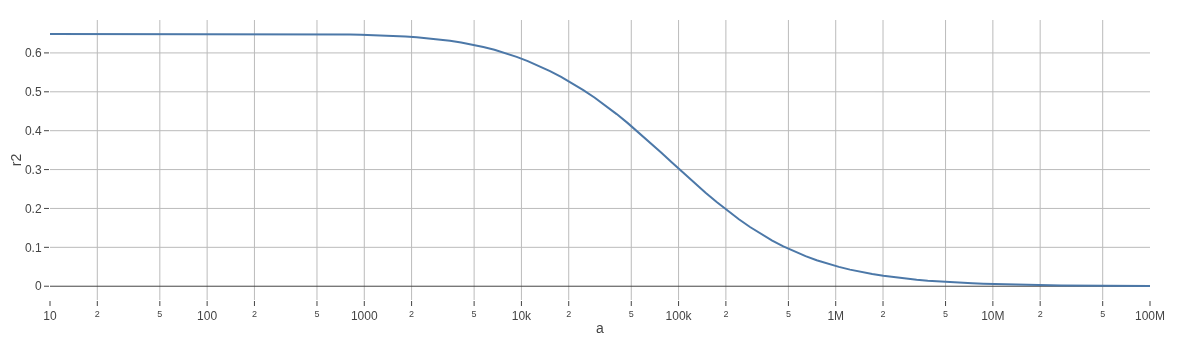

In [109]:
px.line(coef_df, x='a', y='r2', log_x=True, width = 1200).show(renderer='png', width = 1200, height=350)

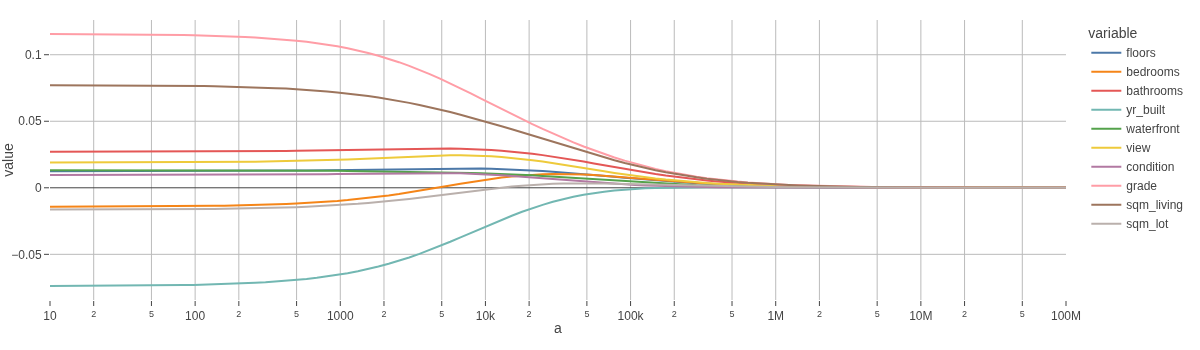

In [110]:
px.line(coef_df, x='a', y=['floors', 'bedrooms', 'bathrooms', 'yr_built', 'waterfront', 'view',
       'condition', 'grade', 'sqm_living', 'sqm_lot'], log_x=True).show(renderer='png', width = 1200, height=350)

In [111]:
coef_df = pd.DataFrame(data=0.0, index=range(100), columns=['a', 'r2', 'intercept'] + [*X_train.columns.values])
i=0
for a in np.logspace(start=-4, stop=4, num=100, base=10):
    lasso_test = Lasso(alpha=a, random_state=42, max_iter=10000)
    lasso_test.fit(X_train_scaled, y_train)
    coef_df.loc[i, 'a'] = a
    coef_df.loc[i, 'r2'] = lasso_test.score(X_train_scaled, y_train)
    coef_df.loc[i, 'intercept'] = lasso_test.intercept_
    coef_df.loc[i, 'floors':] = lasso_test.coef_
    i+=1
coef_df

,a,r2,intercept,floors,bedrooms,bathrooms,yr_built,waterfront,view,condition,grade,sqm_living,sqm_lot
0,0.000100,0.648663,5.665443,0.012261,-0.013986,0.026898,-0.073664,0.013204,0.018900,0.009426,0.115650,0.076907,-0.016298
1,0.000120,0.648662,5.665443,0.012245,-0.013926,0.026869,-0.073616,0.013190,0.018901,0.009408,0.115645,0.076855,-0.016269
2,0.000145,0.648661,5.665443,0.012227,-0.013854,0.026834,-0.073558,0.013173,0.018901,0.009387,0.115636,0.076794,-0.016234
3,0.000175,0.648658,5.665443,0.012203,-0.013767,0.026792,-0.073489,0.013152,0.018902,0.009361,0.115629,0.076719,-0.016192
4,0.000210,0.648655,5.665443,0.012177,-0.013663,0.026740,-0.073406,0.013127,0.018902,0.009330,0.115618,0.076632,-0.016141
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,4750.810162,0.000000,5.665443,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
96,5722.367659,0.000000,5.665443,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
97,6892.612104,0.000000,5.665443,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
98,8302.175681,0.000000,5.665443,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


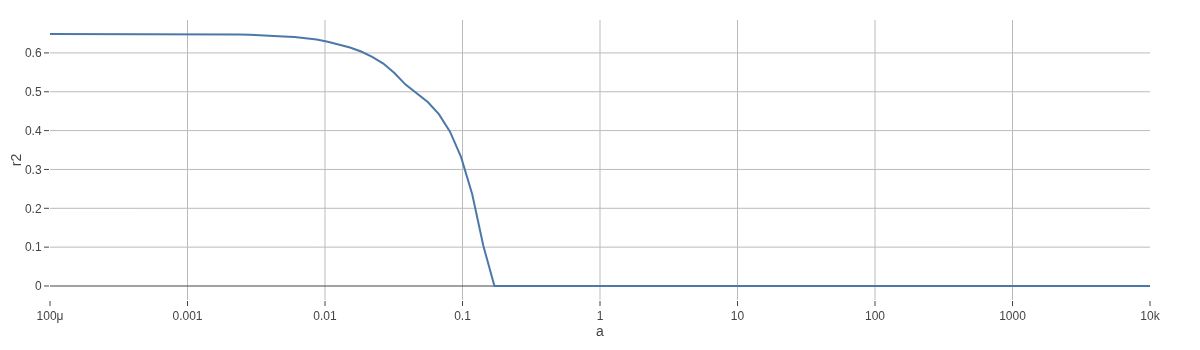

In [112]:
px.line(coef_df, x='a', y='r2', log_x=True, width = 1200).show(renderer='png', width = 1200, height=350)

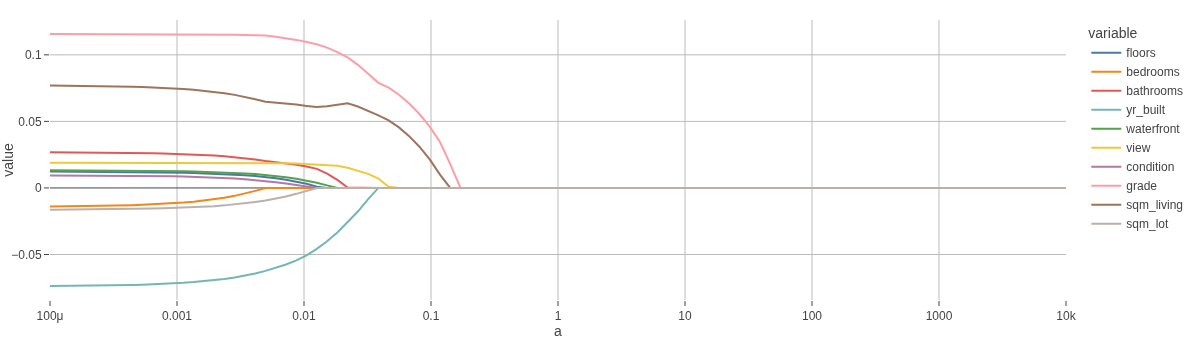

In [113]:
px.line(coef_df, x='a', y=['floors', 'bedrooms', 'bathrooms', 'yr_built', 'waterfront', 'view',
       'condition', 'grade', 'sqm_living', 'sqm_lot'], log_x=True).show(renderer='png', width = 1200, height=350)

In [114]:
coef_df = pd.DataFrame(data=0.0, index=range(100), columns=['a', 'r2', 'intercept'] + [*X_train.columns.values])
i=0
for a in np.logspace(start=-4, stop=4, num=100, base=10):
    elastic_test = ElasticNet(alpha=a, l1_ratio=0.2 ,random_state=42, max_iter=10000)
    elastic_test.fit(X_train_scaled, y_train)
    coef_df.loc[i, 'a'] = a
    coef_df.loc[i, 'r2'] = elastic_test.score(X_train_scaled, y_train)
    coef_df.loc[i, 'intercept'] = elastic_test.intercept_
    coef_df.loc[i, 'floors':] = elastic_test.coef_
    i+=1

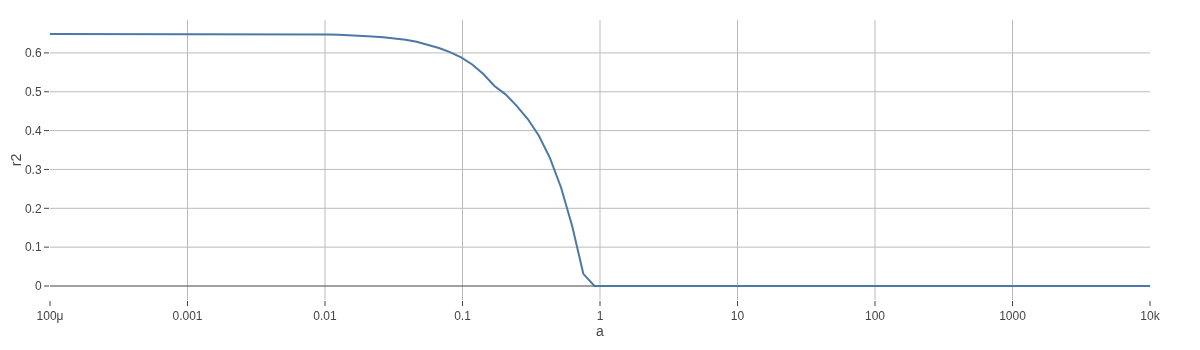

In [115]:
px.line(coef_df, x='a', y='r2', log_x=True, width = 1200).show(renderer='png', width = 1200, height=350)

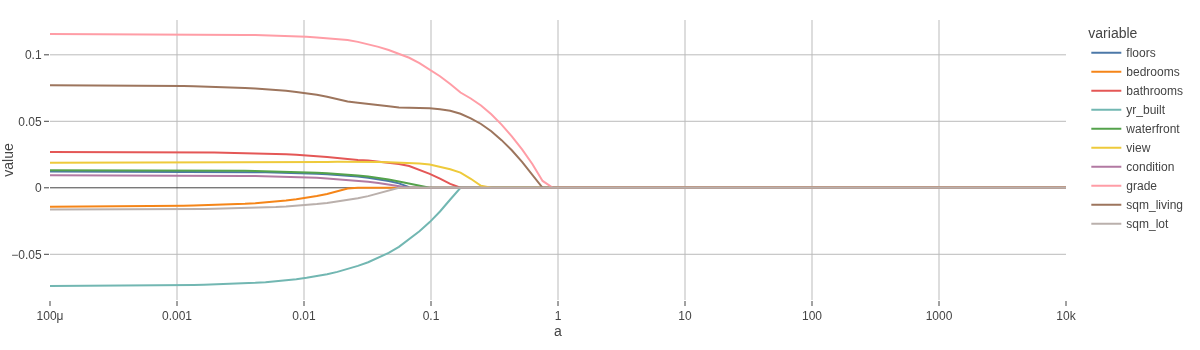

In [117]:
px.line(coef_df, x='a', y=['floors', 'bedrooms', 'bathrooms', 'yr_built', 'waterfront', 'view',
       'condition', 'grade', 'sqm_living', 'sqm_lot'], log_x=True).show(renderer='png', width = 1200, height=350)